# 04 — Data Preprocessing
**Goal:** Build the data pipeline that turns raw tables into model-ready
matrices. Sources: Géron Ch2, ISLR Ch3 prep, Kuhn & Johnson (2013)
*Applied Predictive Modeling*.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/learning_courses')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
np.random.seed(4)

## 1. The cardinal rule

**Fit all preprocessing on the training set only. Apply the fitted
transformer to validation and test.** This single rule prevents the most
common data leak in applied ML — and most production pipelines fail because
it was ignored.

In [2]:
# Mini-example: scaler fitted on ALL data leaks the test mean/std
np.random.seed(0)
X_train = np.random.normal(0, 1, 100).reshape(-1, 1)
X_test  = np.random.normal(0, 1, 50).reshape(-1, 1)

scaler_wrong = StandardScaler().fit(np.vstack([X_train, X_test]))
scaler_right = StandardScaler().fit(X_train)

print('test mean (raw)        :', X_test.mean())
print('scaled WRONG (fit on all): mean of transformed test =', scaler_wrong.transform(X_test).mean())
print('scaled RIGHT (fit train): mean of transformed test =', scaler_right.transform(X_test).mean())
print('  -> wrong is closer to 0 because the test mean leaked into the fit')

test mean (raw)        : 0.25653484014883293
scaled WRONG (fit on all): mean of transformed test = 0.1285468215310874
scaled RIGHT (fit train): mean of transformed test = 0.19518830264706996
  -> wrong is closer to 0 because the test mean leaked into the fit


## 2. Why scaling matters

Distance- and gradient-based models care about the *units* of every feature.
A feature in dollars (10⁵) and a feature in years (10⁰) will dominate a
distance metric in completely different ways.

**Scale-sensitive algorithms:**
- k-NN
- SVM (with RBF or polynomial kernel)
- Neural networks (and PCA)
- Regularized linear models (Lasso / Ridge)

**Scale-invariant algorithms:**
- Tree-based models (Random Forest, GBDT)
- Naive Bayes (with Gaussian likelihood)
- Linear regression without regularization

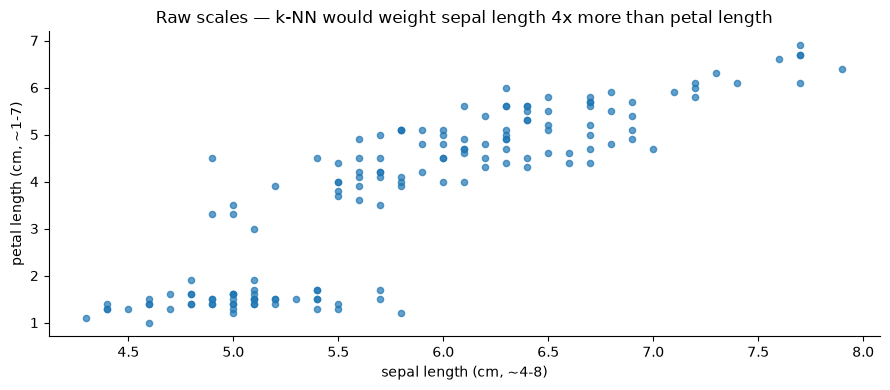

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
from sklearn.datasets import load_iris
X = load_iris().data
ax.scatter(X[:, 0], X[:, 2], s=20, alpha=0.7)
ax.set_xlabel('sepal length (cm, ~4-8)')
ax.set_ylabel('petal length (cm, ~1-7)')
ax.set_title('Raw scales — k-NN would weight sepal length 4x more than petal length')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 3. The three scalers you actually use

| Scaler | Formula | When to use |
|---|---|---|
| **StandardScaler** | (x - μ) / σ | Default for most cases; assumes roughly Gaussian |
| **MinMaxScaler** | (x - min) / (max - min) | When you need values in [0, 1] (neural nets) |
| **RobustScaler** | (x - median) / IQR | When outliers dominate; uses median + IQR |

Two failure modes of StandardScaler:
1. **Heavy tails** — σ is pulled by outliers, the bulk of the data gets
   compressed to near-zero.
2. **Bimodal** — the mean is between modes and subtracting it is meaningless.

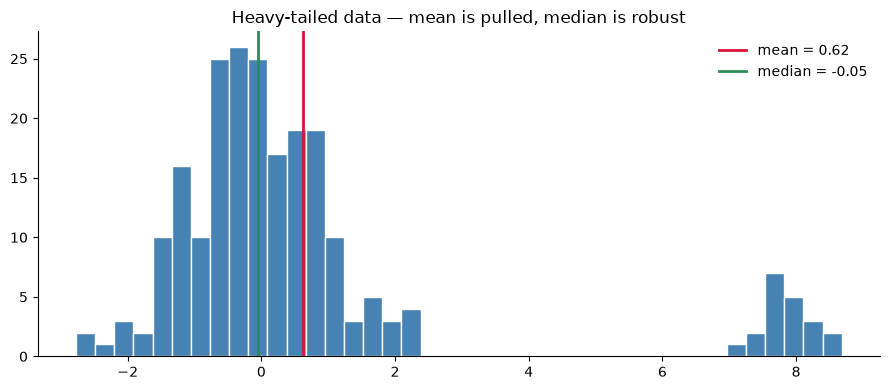

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.concatenate([np.random.normal(0, 1, 200), np.random.normal(8, 0.5, 20)])
ax.hist(x, bins=40, color='steelblue', edgecolor='white')
ax.axvline(x.mean(), color='crimson', lw=2, label=f'mean = {x.mean():.2f}')
ax.axvline(np.median(x), color='seagreen', lw=2, label=f'median = {np.median(x):.2f}')
ax.legend(frameon=False)
ax.set_title('Heavy-tailed data — mean is pulled, median is robust')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 4. Encoding categorical features

Categorical features cannot be put in a matrix as integers (the model would
treat them as ordinal). Three choices:

1. **One-hot encoding** (a.k.a. dummy variables) — one column per category,
   0/1. Safe but explodes column count for high-cardinality features.
2. **Ordinal encoding** — assign an integer to each category. Only valid when
   the categories have a natural order ("low" < "medium" < "high").
3. **Target encoding** — replace each category with the mean of the target
   for that category. Powerful but easy to leak — must be done within CV.
4. **Embeddings** — learn a dense vector per category (notebook 12).

In [5]:
colors = pd.DataFrame({'color': ['red', 'green', 'blue', 'green', 'red', 'red']})
enc = OneHotEncoder(sparse_output=False)
print('one-hot of a 3-category feature:')
print(enc.fit_transform(colors))

one-hot of a 3-category feature:
[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]]


## 5. The `ColumnTransformer` — the right way

In a real pipeline you have numeric and categorical features side by side.
`ColumnTransformer` lets you apply different preprocessing to each subset
and stitch them together.

In [6]:
df = pd.DataFrame({
    'age'        : [25, 40, 35, 50, 28, 60, 45],
    'income'     : [50, 80, 60, 100, 45, 120, 90],
    'channel'    : ['Search','Social','Search','Email','Display','Search','Social'],
    'subscribed' : [0, 1, 0, 1, 0, 1, 1],
})
X = df.drop(columns='subscribed'); y = df['subscribed']

num_features = ['age', 'income']
cat_features = ['channel']

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
pre = ColumnTransformer([
    ('num', num_pipe, num_features),
    ('cat', cat_pipe, cat_features),
])
X_t = pre.fit_transform(X)
print('column names :', pre.get_feature_names_out())
print('output shape :', X_t.shape)
print('output (first 3 rows):')
print(np.round(X_t[:3], 3))

column names : ['num__age' 'num__income' 'cat__channel_Display' 'cat__channel_Email'
 'cat__channel_Search' 'cat__channel_Social']
output shape : (7, 6)
output (first 3 rows):
[[-1.347 -1.088  0.     0.     1.     0.   ]
 [-0.037  0.084  0.     0.     0.     1.   ]
 [-0.474 -0.697  0.     0.     1.     0.   ]]


## 6. Missing values — three strategies

1. **Drop** rows/columns with missing values. Last resort.
2. **Impute** with mean / median / mode / a model. Default.
3. **Treat missingness as a signal** — add a binary indicator feature. Often
   the most informative choice.

**Critical:** impute using the training-set mean/median, then apply the
same imputation to test. Use `Pipeline` to enforce this.

In [7]:
df_miss = pd.DataFrame({'x': [1, 2, np.nan, 4, 5, np.nan, 7]})
print('mean impute:', SimpleImputer(strategy='mean').fit_transform(df_miss).ravel())
print('median impute:', SimpleImputer(strategy='median').fit_transform(df_miss).ravel())
print('add indicator:')
imp = SimpleImputer(strategy='mean', add_indicator=True)
print(imp.fit_transform(df_miss))

mean impute: [1.  2.  3.8 4.  5.  3.8 7. ]
median impute: [1. 2. 4. 4. 5. 4. 7.]
add indicator:
[[1.  0. ]
 [2.  0. ]
 [3.8 1. ]
 [4.  0. ]
 [5.  0. ]
 [3.8 1. ]
 [7.  0. ]]


## 7. Train / val / test split

Three sets, three jobs:

| Set | Used for |
|---|---|
| **Train** | fit the model |
| **Validation** | tune hyperparameters, pick between models |
| **Test** | final, *one-time* estimate of generalization |

Common ratios: 60/20/20 or 70/15/15 (small n) or 80/10/10 (large n).
**Never look at the test set until you are done.**

For small n, prefer **k-fold cross-validation** on train+val, hold out a
test set only for the final number. (Notebook 07.)

In [8]:
from sklearn.model_selection import train_test_split
X_demo = np.arange(1000).reshape(-1, 1)
y_demo = (X_demo.ravel() % 7 == 0).astype(int)
X_tr, X_rest, y_tr, y_rest = train_test_split(X_demo, y_demo, test_size=0.3, random_state=0, stratify=y_demo)
X_va, X_te, y_va, y_te       = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0, stratify=y_rest)
print(f'train: {len(X_tr)}  val: {len(X_va)}  test: {len(X_te)}')

train: 700  val: 150  test: 150


## 8. The full pipeline — `Pipeline` chains fit and transform

`Pipeline(steps).fit(X_train).transform(X_test)` is the single object that
keeps the entire preprocessing honest. It is also what sklearn expects for
cross-validation, GridSearch, and deployment.

In [9]:
from sklearn.linear_model import LogisticRegression
full_pipe = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=500)),
])
from sklearn.model_selection import cross_val_score
scores = cross_val_score(full_pipe, X, y, cv=3, scoring='accuracy')
print(f'3-fold CV accuracy: {scores.mean():.3f} \u00b1 {scores.std():.3f}')

3-fold CV accuracy: 1.000 ± 0.000


## 9. Class imbalance

When one class is 1% of the data, accuracy is useless. Three responses:

1. **Resample** — oversample minority (SMOTE), undersample majority, or both.
2. **Class weights** — `class_weight='balanced'` in most sklearn classifiers.
3. **Pick a better metric** — F1, PR-AUC, recall@k, not accuracy.
4. **Threshold tuning** — default 0.5 is rarely optimal on imbalanced data.

In [10]:
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
X, y = make_classification(n_samples=2000, weights=[0.98, 0.02], random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
m1 = LogisticRegression(max_iter=500).fit(X_tr, y_tr)
m2 = LogisticRegression(max_iter=500, class_weight='balanced').fit(X_tr, y_tr)
for name, m in [('default', m1), ('balanced', m2)]:
    print(f'\n=== {name} ===')
    print(classification_report(y_te, m.predict(X_te), digits=3, zero_division=0))


=== default ===
              precision    recall  f1-score   support

           0      0.994     1.000     0.997       487
           1      1.000     0.769     0.870        13

    accuracy                          0.994       500
   macro avg      0.997     0.885     0.933       500
weighted avg      0.994     0.994     0.994       500


=== balanced ===
              precision    recall  f1-score   support

           0      0.996     0.920     0.956       487
           1      0.220     0.846     0.349        13

    accuracy                          0.918       500
   macro avg      0.608     0.883     0.653       500
weighted avg      0.975     0.918     0.940       500



## 10. Data leakage — the silent killer

Leakage happens when information from the test set influences training.
Common sources:

- Preprocessing fit on the full dataset before splitting.
- Using the target to create a feature (e.g. count of past defaults).
- Duplicate rows split between train and test.
- Group leakage (e.g. user A in train and user A in test).
- Time leakage (training on data from the future).

The fix is the same every time: **anything that uses the target, or any
statistic computed across rows, must be computed within a CV fold**.

## Summary

| Topic | Rule |
|---|---|
| Scaling | Fit on train only; StandardScaler default |
| Encoding | One-hot for nominal; ordinal for ordered; target within CV |
| Missing | Impute within CV; missing-indicator often helps |
| Splits | Train / val / test, three jobs, look at test once |
| Imbalance | Class weights + better metrics + threshold tuning |
| Leakage | Anything target-related or row-aggregated must be inside CV |
| Pipeline | The single object that enforces all of the above |

**Next:** `05_linear_regression_deep_dive.ipynb` — the first model.